In [21]:
import uuid
import random
!pip install networkx matplotlib
!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [22]:
# ==============================
# CONFIGURACIÓN DE LA ENTRADA
# ==============================

modo = "manual"  # "manual" o "aleatorio"

# Si modo = "manual", modifica únicamente esta lista
arbol = [
    [
        [
            [3, 5],
            [2, 7]
        ],
        [
            [8, 1],
            [4, 6]
        ]
    ],
    [
        [
            [9, 2],
            [5, 10]
        ],
        [
            [7, 4],
            [6, 8]
        ]
    ]
]



In [23]:
class Nodo:

    def __init__(self, valor=None):
        self.id = uuid.uuid4()
        self.valor = valor
        self.hijos = []
        self.podado = True
        self.visitado = False
        self.optimo = False


def lista_a_nodo(lista):
    nodo = Nodo()

    for elemento in lista:

        if isinstance(elemento, list):
            hijo = lista_a_nodo(elemento)
            nodo.hijos.append(hijo)

        else:
            hijo = Nodo(elemento)
            nodo.hijos.append(hijo)

    return nodo

In [24]:
def min(arbol, alpha, beta, camino, nivel):

    mismoPdre = False
    alphaMentira = alpha
    betaMentira = beta

    mejorValor = float("inf")
    mejorCamino = camino.copy()

    camino.append(arbol.id)
    nivel = nivel + 1

    for elemento in arbol.hijos:
        elemento.podado = False

        if elemento.hijos:

            # Tiene hijos, seguimos bajando
            alphaMentira, caminoMentira = max(
                elemento,
                alpha,
                beta,
                camino.copy(),
                nivel
            )

            if alphaMentira < mejorValor:

                mejorValor = alphaMentira
                mejorCamino = caminoMentira

            if alphaMentira < beta:
                beta = alphaMentira

            if alpha >= beta:
                break

        else:

            elemento.podado = False

            if elemento.valor < mejorValor:

                mejorValor = elemento.valor

                mejorCamino = camino[:nivel]
                mejorCamino.append(elemento.id)

            if elemento.valor < beta:
                beta = elemento.valor

            if alpha >= beta:
                break

    arbol.podado = False

    camino = mejorCamino

    return mejorValor, camino


def max(arbol, alpha, beta, camino, nivel):

    mismoPdre = False
    alphaMentira = alpha
    betaMentira = beta

    mejorValor = float("-inf")
    mejorCamino = camino.copy()

    camino.append(arbol.id)
    nivel = nivel + 1

    for elemento in arbol.hijos:
        elemento.podado = False

        if elemento.hijos:

            # Tiene hijos, seguimos bajando
            betaMentira, caminoMentira = min(
                elemento,
                alpha,
                beta,
                camino.copy(),
                nivel
            )

            if betaMentira > mejorValor:

                mejorValor = betaMentira
                mejorCamino = caminoMentira

            if betaMentira > alpha:
                alpha = betaMentira

            if alpha >= beta:
                break

        else:

            elemento.podado = False

            if elemento.valor > mejorValor:

                mejorValor = elemento.valor

                mejorCamino = camino[:nivel]
                mejorCamino.append(elemento.id)

            if elemento.valor > alpha:
                alpha = elemento.valor

            if alpha >= beta:
                break

    arbol.podado = False

    camino = mejorCamino

    return mejorValor, camino
def buscar_nodo(nodo, id_buscado):

    if nodo.id == id_buscado:
        return nodo

    for hijo in nodo.hijos:
        resultado = buscar_nodo(hijo, id_buscado)

        if resultado is not None:
            return resultado

    return None
def mostrar_camino(raiz, camino):

    print("Camino:")

    for id_nodo in camino:

        nodo = buscar_nodo(raiz, id_nodo)

        if nodo.valor is None:
            print("Nodo", nodo.id, "→ nodo interno")
        else:
            print("Nodo", nodo.id, "→ valor:", nodo.valor)

In [25]:
def repartir(numero, sumandos):
    puntos = sorted(random.sample(range(1, numero), sumandos - 1))
    numeros = []
    anterior = 0
    for punto in puntos:
        numeros.append(punto - anterior)
        anterior = punto
    numeros.append(numero - anterior)
    return numeros


def generar_entrada(niveles:int, nodos:int):
    if niveles < 1 or niveles > 5:
        print("El numero de niveles debe estar entre 2 y 5")
        return ""
    if nodos < 1 or nodos > 50:
        print("El numero de nodos debe estar entre 1 y 50")
        return ""

    if niveles == 1:
        return [random.randint(-30, 30) for _ in range(nodos)]

    divisiones = random.randint(1, nodos)
    como_repartir = repartir(nodos, divisiones)

    arbol = []
    for cantidad in como_repartir:
        arbol.append(generar_entrada(niveles - 1, cantidad))
    return arbol

In [26]:
def marcar_camino_optimo(raiz, camino):

    for id_nodo in camino:

        nodo = buscar_nodo(raiz, id_nodo)

        if nodo is not None:
            nodo.optimo = True


def construir_grafo(nodo, grafo=None, nivel=0):

    if grafo is None:
        grafo = nx.DiGraph()

    grafo.add_node(
        nodo.id,
        objeto=nodo,
        nivel=nivel
    )

    for hijo in nodo.hijos:

        grafo.add_edge(
            nodo.id,
            hijo.id
        )

        construir_grafo(
            hijo,
            grafo,
            nivel + 1
        )

    return grafo


def calcular_posiciones(raiz):

    posiciones = {}

    contador = [0]

    def recorrer(nodo, nivel):

        if not nodo.hijos:

            x = contador[0]
            contador[0] += 1

        else:

            posiciones_hijos = []

            for hijo in nodo.hijos:

                posicion_hijo = recorrer(
                    hijo,
                    nivel + 1
                )

                posiciones_hijos.append(
                    posicion_hijo
                )

            x = sum(posiciones_hijos) / len(posiciones_hijos)

        posiciones[nodo.id] = (
            x,
            -nivel
        )

        return x

    recorrer(
        raiz,
        0
    )

    return posiciones


def dibujar_arbol(raiz, camino, resultado):

    # Marcar los nodos del camino óptimo
    marcar_camino_optimo(
        raiz,
        camino
    )

    # Crear grafo
    grafo = construir_grafo(
        raiz
    )

    # Calcular posición de cada nodo
    posiciones = calcular_posiciones(
        raiz
    )

    colores_nodos = []

    etiquetas = {}

    # ---------------------------------
    # Preparar colores y etiquetas
    # ---------------------------------

    for id_nodo in grafo.nodes:

        nodo = grafo.nodes[id_nodo]["objeto"]
        nivel = grafo.nodes[id_nodo]["nivel"]

        # Si es hoja
        if nodo.valor is not None:

            etiquetas[id_nodo] = str(
                nodo.valor
            )

        # Si es nodo interno
        else:

            if nivel % 2 == 0:
                etiquetas[id_nodo] = "MAX"

            else:
                etiquetas[id_nodo] = "MIN"

        # Camino óptimo
        if nodo.optimo:

            colores_nodos.append(
                "lightgreen"
            )

        # Nodo podado
        elif nodo.podado:

            colores_nodos.append(
                "lightcoral"
            )

        # Nodo visitado pero no óptimo
        else:

            colores_nodos.append(
                "lightblue"
            )

    # ---------------------------------
    # Separar los diferentes tipos
    # de conexiones
    # ---------------------------------

    conexiones_optimas = []
    conexiones_podadas = []
    conexiones_normales = []

    # Pares consecutivos del camino óptimo
    camino_conexiones = []

    for i in range(len(camino) - 1):

        camino_conexiones.append(
            (
                camino[i],
                camino[i + 1]
            )
        )

    for padre, hijo in grafo.edges:

        nodo_hijo = grafo.nodes[hijo]["objeto"]

        if (padre, hijo) in camino_conexiones:

            conexiones_optimas.append(
                (padre, hijo)
            )

        elif nodo_hijo.podado:

            conexiones_podadas.append(
                (padre, hijo)
            )

        else:

            conexiones_normales.append(
                (padre, hijo)
            )

    # ---------------------------------
    # Dibujar
    # ---------------------------------

    plt.figure(
        figsize=(16, 9)
    )

    # Dibujar nodos
    nx.draw_networkx_nodes(
        grafo,
        posiciones,
        node_color=colores_nodos,
        node_size=1300,
        edgecolors="black"
    )

    # Dibujar textos
    nx.draw_networkx_labels(
        grafo,
        posiciones,
        labels=etiquetas,
        font_size=9,
        font_weight="bold"
    )

    # Conexiones normales
    nx.draw_networkx_edges(
        grafo,
        posiciones,
        edgelist=conexiones_normales,
        width=1.5,
        arrows=False
    )

    # Conexiones podadas
    nx.draw_networkx_edges(
        grafo,
        posiciones,
        edgelist=conexiones_podadas,
        width=2,
        edge_color="red",
        style="dashed",
        arrows=False
    )

    # Camino óptimo
    nx.draw_networkx_edges(
        grafo,
        posiciones,
        edgelist=conexiones_optimas,
        width=4,
        edge_color="green",
        arrows=False
    )

    # ---------------------------------
    # Leyenda
    # ---------------------------------

    leyenda = [

        Patch(
            facecolor="lightgreen",
            edgecolor="black",
            label="Camino óptimo"
        ),

        Patch(
            facecolor="lightblue",
            edgecolor="black",
            label="Nodo evaluado"
        ),

        Patch(
            facecolor="lightcoral",
            edgecolor="black",
            label="Nodo podado"
        ),

        Line2D(
            [0],
            [0],
            color="green",
            linewidth=4,
            label="Secuencia óptima"
        ),

        Line2D(
            [0],
            [0],
            color="red",
            linewidth=2,
            linestyle="--",
            label="Rama podada"
        )
    ]

    plt.legend(
        handles=leyenda,
        loc="upper left"
    )

    plt.title(
        "Árbol de Poda Alfa-Beta\n"
        + "Valor óptimo: "
        + str(resultado),
        fontsize=16
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

Seleccione el tipo de entrada:
1. Usar árbol definido manualmente
2. Generar árbol aleatoriamente
Opción:  2
Ingrese el número de niveles (1-5):  3
Ingrese el número de nodos hoja (1-50):  10


Árbol utilizado:
[[[12]], [[-18, 20]], [[27]], [[-16, 7]], [[1], [8], [5], [-26]]]
Resultado: 27
Camino encontrado:
Camino:
Nodo 43ae3fc7-aacc-48be-b883-c0f4cd43b151 → nodo interno
Nodo 2c56c305-7f9e-4a96-9cc9-cf23a66152ab → nodo interno
Nodo 0880c1ed-03b7-4abb-abbe-76d621ba745b → nodo interno
Nodo 4587b46a-7d7a-4e88-b0d9-83353f636576 → valor: 27


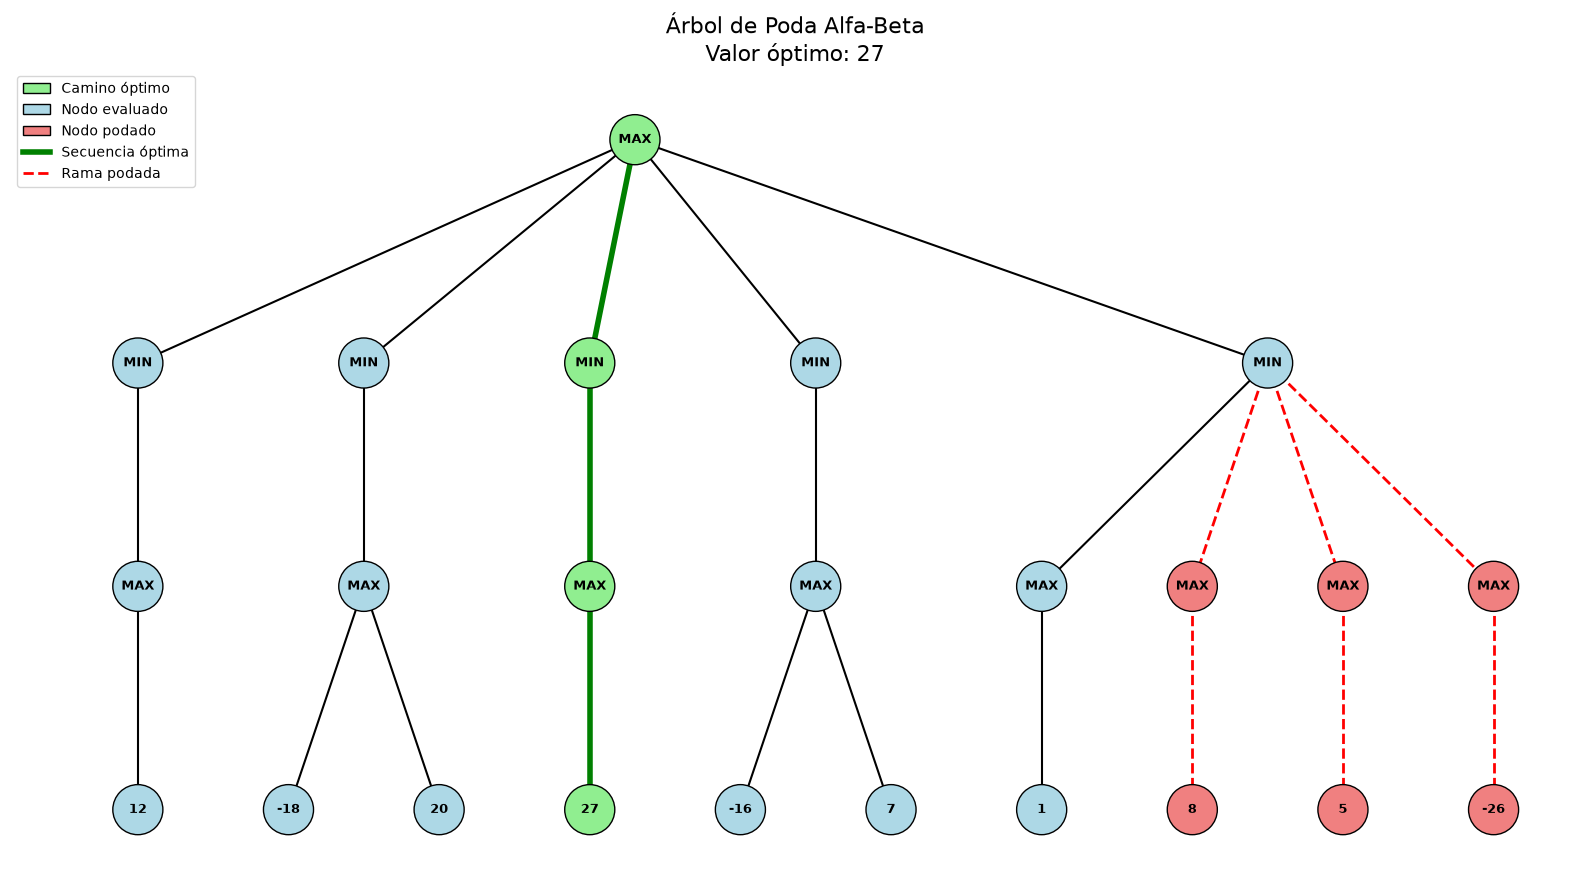

In [28]:
opcion = input(
    "Seleccione el tipo de entrada:\n"
    "1. Usar árbol definido manualmente\n"
    "2. Generar árbol aleatoriamente\n"
    "Opción: "
)

if opcion == "1":
    entrada = arbol

elif opcion == "2":
    while True:
        niveles = int(input("Ingrese el número de niveles (1-5): "))
    
        if 1 <= niveles <= 5:
            break
    
        print("Error: los niveles deben estar entre 1 y 5.")
    
    
    while True:
        nodos_hoja = int(input("Ingrese el número de nodos hoja (1-50): "))
    
        if 1 <= nodos_hoja <= 50:
            break
    
        print("Error: los nodos hoja deben estar entre 1 y 50.")
    
    
    entrada = generar_entrada(niveles, nodos_hoja)

else:
    raise ValueError("Opción no válida")

print("Árbol utilizado:")
print(entrada)
raiz = lista_a_nodo(entrada)

camino = []

alpha = float("-inf")
beta = float("inf")

alpha, camino = max(
    raiz,
    alpha,
    beta,
    camino,
    0
)

print("Resultado:", alpha)

print("Camino encontrado:")
mostrar_camino(raiz, camino)

dibujar_arbol(
    raiz,
    camino,
    alpha
)

In [ ]:
!pip install networkx